In [1]:
import json
import argparse
import itertools

In [2]:
import torch
import numpy as np 
from torch import nn
from rich.console import Group
from rich.live import Live
from rich.panel import Panel
from rich.progress import Progress

from fintorch.deep.dtype import Dataset
from fintorch.deep.model import *
from fintorch.deep.module import Module
from fintorch.deep.transform.feature import *
from fintorch.deep.transform.label import *
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.enum import TimeFrame
from fintorch.deep.metrics import Metrics
from fintorch.setting import RICH_PROGRESS_COLUMNS
from fintorch.utils.timestamp import create_timestamps

# Define Hyper Parameters

In [3]:
SYMBOL = "BTC-USDT"
TIME_FRAME = TimeFrame.DAY1

DIM_SEQUENCE = 32 
NUM_HIDDEN_LAYERS = 2
BATCH_NORM = True
DROPOUT = 0.5

EPOCH = 10
BATCH_SIZE = 128
LR = 1e-3
WEIGTH_DECAY = 1e-1

START_DATE = "2023-01-01"
STOP_DATE = "2024-06-01"
INTERVAL = TimeFrame.MIN15

# Create Module

In [4]:
# create feature and label transforms and dataset
feature_transform = RollingMeanStdTrRocFeatureTransform(symbol=SYMBOL, time_frame=TIME_FRAME, dim_sequence=DIM_SEQUENCE)
label_transform = ForwardMiddleSmaLabelTransform(symbol=SYMBOL, time_frame=TIME_FRAME, backward=51)
dataset = Dataset(feature_transform=feature_transform, label_transform=label_transform, interval=INTERVAL)

# define model type and kwargs
model_type = GRU
model_kwargs = {
    "dim_sequence": DIM_SEQUENCE,
    "dim_feature": 4,
    "dim_output": 2,
    "num_hidden_layers": NUM_HIDDEN_LAYERS,
    "batch_norm": BATCH_NORM,
    "dropout": DROPOUT,
    "activation_fn": nn.Softmax(dim=-1)
}


# create module
module = Module(dataset=dataset, model_type=model_type, model_kwargs=model_kwargs, epoch=EPOCH, batch_size=BATCH_SIZE, lr=LR, weight_decay=WEIGTH_DECAY)
module.directory

# Load data collection and optimize module

In [5]:
dc = ONLINE_EXCHANGE.future.data.get_data_collection(symbols=[module.symbol], time_frames=[module.time_frame])

with Live(refresh_per_second=2) as live, module:
    for status in module.optimize(dc=dc, start_date=START_DATE):
        live.update(Panel.fit(str(status), title=str(module)))

Output()

# Evaluate Module

In [6]:
timestamps = create_timestamps(start_date=START_DATE, stop_date=STOP_DATE, interval=TIME_FRAME)

# create y and y_hat values
with module:
    sf_generator = module.dataset.label_transform.transform_sf(dc=dc, timestamps=timestamps)
    y_array = np.concatenate([sf for sf in sf_generator if sf is not None])
    timestamps = timestamps[:len(y_array)]
    y_hat_dict = module.predict(dc=dc, timestamps=timestamps, mode="val")

# convert y and y_hat values to torch.Tensor
y = torch.from_numpy(y_array)
y_hat = torch.from_numpy(np.array(list(y_hat_dict.values())))


# calculate metrics
metrics = Metrics(criterion=module.trainer.criterion, y=y, y_hat=y_hat)

print("Loss:        {:.4f}".format(metrics.objective))
print("Accuracy:    {:.2f}".format(metrics.accuracy))
print("Recall-UP:   {:.2f} Precision-UP:   {:.2f}".format(metrics.recall(label=1), metrics.precision(label=1)))
print("Recall-Down: {:.2f} Precision-Down: {:.2f}".format(metrics.recall(label=0), metrics.precision(label=0)))

Loss:        0.3298
Accuracy:    82.55
Recall-UP:   86.33 Precision-UP:   89.22
Recall-Down: 72.64 Precision-Down: 66.96


# Draw perdictions plot

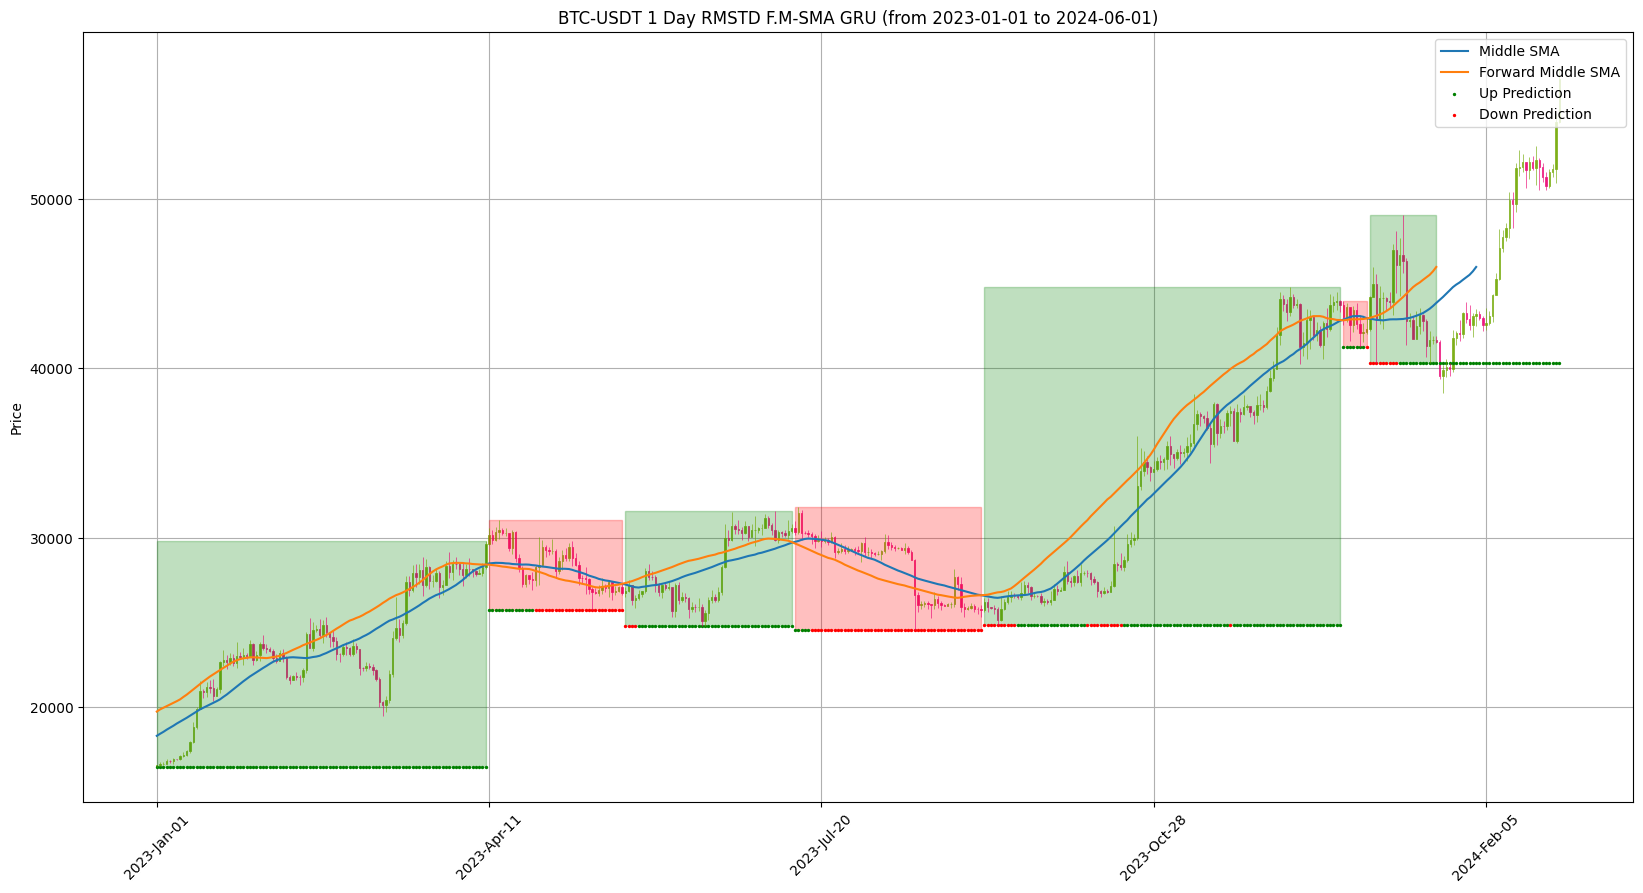

In [7]:
with module:
    module.show_ohlc_plot(dc=dc, start_date=START_DATE, stop_date=STOP_DATE, mode="val")